In [2]:
import pandas as pd
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geopandas as gpd
from shapely.geometry import Polygon
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

Una vez descargados los archivos y puestos en las carpetas de su clase, se junta todo en un df que contiene la ubicación geografica y la etiqueta asignada a cada negocio:

    Ejemplo, si el archivo se puso en la carpeta de bajos ingresos, el modelo aceptara que ese negocio se asocia a bajos ingresos

In [3]:
base_dir = Path(os.getcwd())

carpetas = [
    elemento for elemento in os.listdir(base_dir ) 
    if os.path.isdir(os.path.join(base_dir , elemento))
    and len(os.listdir(os.path.join(base_dir, elemento))) > 0
    and elemento !="__pycache__"
]


In [4]:
diccionario={}
dfs = []
i = 1

for clase in carpetas:
    ruta = base_dir / clase
    archivos_csv = glob.glob(str(ruta / "*.csv"))
    diccionario[i]=clase
    df_temp = pd.concat([pd.read_csv(f, encoding='latin-1') for f in archivos_csv], ignore_index=True)
    df_temp["clase"] = i
    i += 1
    dfs.append(df_temp)
    
df_final = pd.concat(dfs, ignore_index=True)
df_final = df_final[['Longitud','Latitud','clase']]
df_final.dropna(inplace=True)

df_final.to_csv(base_dir / "Coordenadas_Negocios_Con_Clase_Asociada.csv", index=False)

In [5]:
df_final
diccionario

{1: 'C_AltoPoderAdquisitivo',
 2: 'C_Atraccion_Generacion_Z',
 3: 'C_Trafico_y_Consumo_Impulsivo',
 4: 'C_Universidades',
 5: 'C_Zonas_Residenciales_Delivery'}

In [8]:
import folium

colores_clase = {
    1: 'red',
    2: 'blue',
    3: 'green',
    4: 'purple',
    5: 'orange'
}

mapa = folium.Map(
    location=[df_final['Latitud'].mean(), df_final['Longitud'].mean()], 
    zoom_start=12,
    tiles='CartoDB positron' 
)

for index, row in df_final.iterrows():

    color_punto = colores_clase.get(row['clase'], 'gray')
    
    folium.CircleMarker(
        location=[row['Latitud'], row['Longitud']],
        radius=4,
        color=color_punto,
        fill=True,
        fill_color=color_punto,
        fill_opacity=0.7,
        tooltip=f"Clase: { diccionario[row['clase']]}"
    ).add_to(mapa)

mapa.save("Mapa_Estrategico.html")


¡Exportación exitosa! Tu Shapefile 'Zonas_Potenciales_Negocio.shp' tiene la columna 'score_opp'.


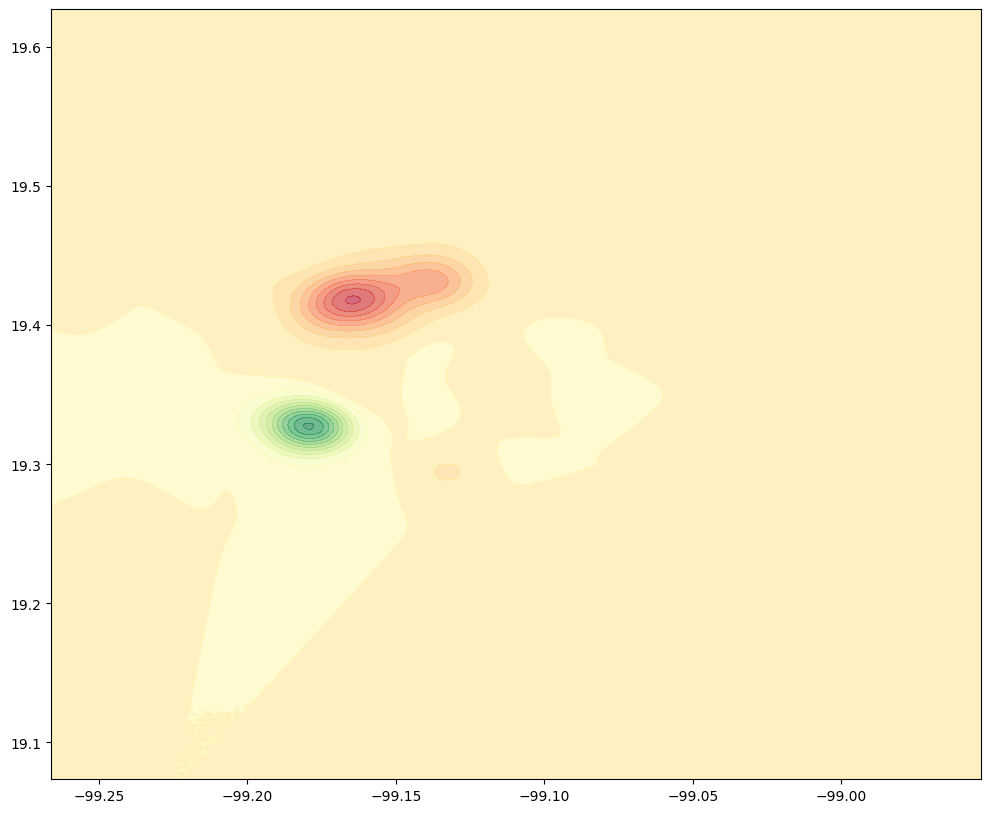

In [7]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[["Longitud", 'Latitud']])
df_final_scaled = pd.DataFrame(X_scaled, columns=["Lon_scaled", "Lat_scaled"])
df_final_scaled["clase"] = df_final["clase"].values

X_mercado = df_final_scaled[df_final_scaled["clase"] == 4][["Lon_scaled", "Lat_scaled"]].values
X_competencia = df_final_scaled[df_final_scaled["clase"] == 2][["Lon_scaled", "Lat_scaled"]].values


kde_mercado = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(X_mercado)
kde_competencia = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(X_competencia)


x_min, x_max = X_scaled[:, 0].min()+1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                    np.arange(y_min, y_max, 0.02))

xy_malla = np.c_[xx.ravel(), yy.ravel()]


Z_mercado = np.exp(kde_mercado.score_samples(xy_malla))
Z_competencia = np.exp(kde_competencia.score_samples(xy_malla))



Z_oportunidad = Z_mercado - (Z_competencia * 1.5)
Z_oportunidad = Z_oportunidad.reshape(xx.shape)

puntos_reales = scaler.inverse_transform(xy_malla)
xx_real = puntos_reales[:, 0].reshape(xx.shape)
yy_real = puntos_reales[:, 1].reshape(yy.shape)


fig, ax = plt.subplots(figsize=(12, 10))


cmap_oportunidad = plt.cm.RdYlGn 


cs = ax.contourf(xx_real, yy_real, Z_oportunidad, levels=20, alpha=0.6, cmap=cmap_oportunidad)

polygons = []
niveles_oportunidad = []
paths = cs.get_paths()

for i, path in enumerate(paths):
    
    score_val = (cs.levels[i] + cs.levels[i+1]) / 2 if i < len(cs.levels)-1 else cs.levels[i]
    
    for poly_coords in path.to_polygons():
        if len(poly_coords) >= 3:
            poly = Polygon(poly_coords).buffer(0)
            if not poly.is_empty:
                polygons.append(poly)
                niveles_oportunidad.append(score_val)

gdf = gpd.GeoDataFrame({'score_opp': niveles_oportunidad, 'geometry': polygons})
gdf.set_crs(epsg=4326, inplace=True)

nombre_archivo = "Zonas_Potenciales_Negocio.shp"
gdf.to_file(nombre_archivo, driver='ESRI Shapefile')

print(f"\n¡Exportación exitosa! Tu Shapefile '{nombre_archivo}' tiene la columna 'score_opp'.")